<a href="https://colab.research.google.com/github/Loopinlogix/House_Predictions/blob/main/Assignment_6_House_Predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get install -y git
!git config --global user.email "crystal_macneil@hotmail.com"
!git config --global user.name "Crystal MacNeil"


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [2]:
!git clone https://github.com/Loopinlogix/House_Predictions.git
%cd colab-git-demo--cm-
!ls


!git status

Cloning into 'House_Predictions'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
[Errno 2] No such file or directory: 'colab-git-demo--cm-'
/content
House_Predictions  sample_data
fatal: not a git repository (or any of the parent directories): .git


Shape: (545, 13)
Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3 

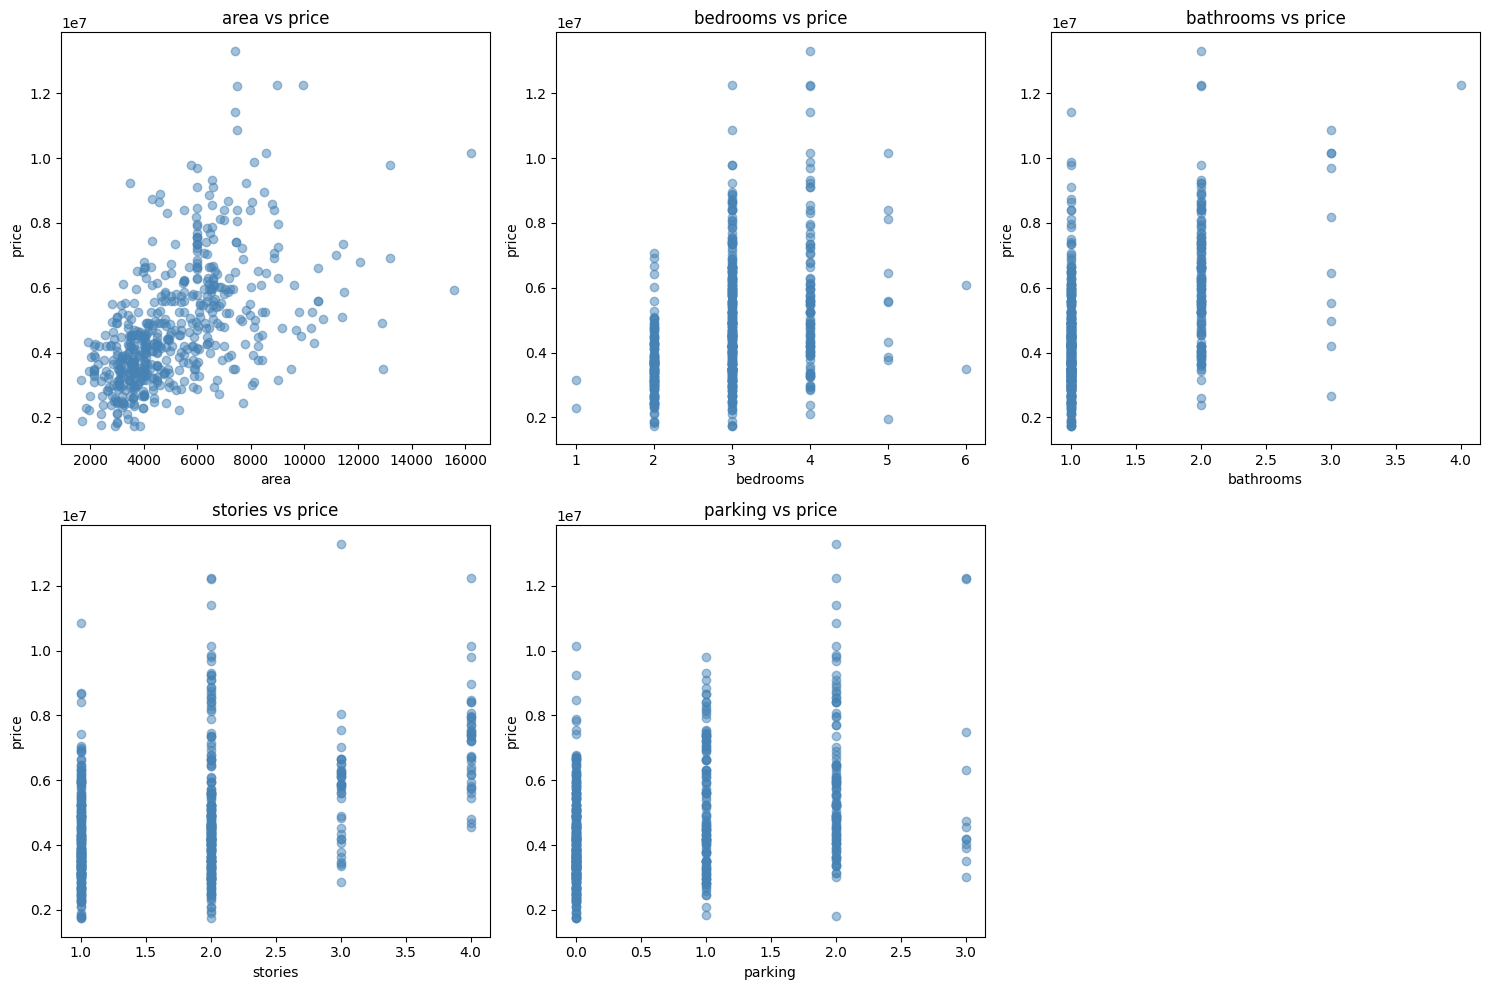

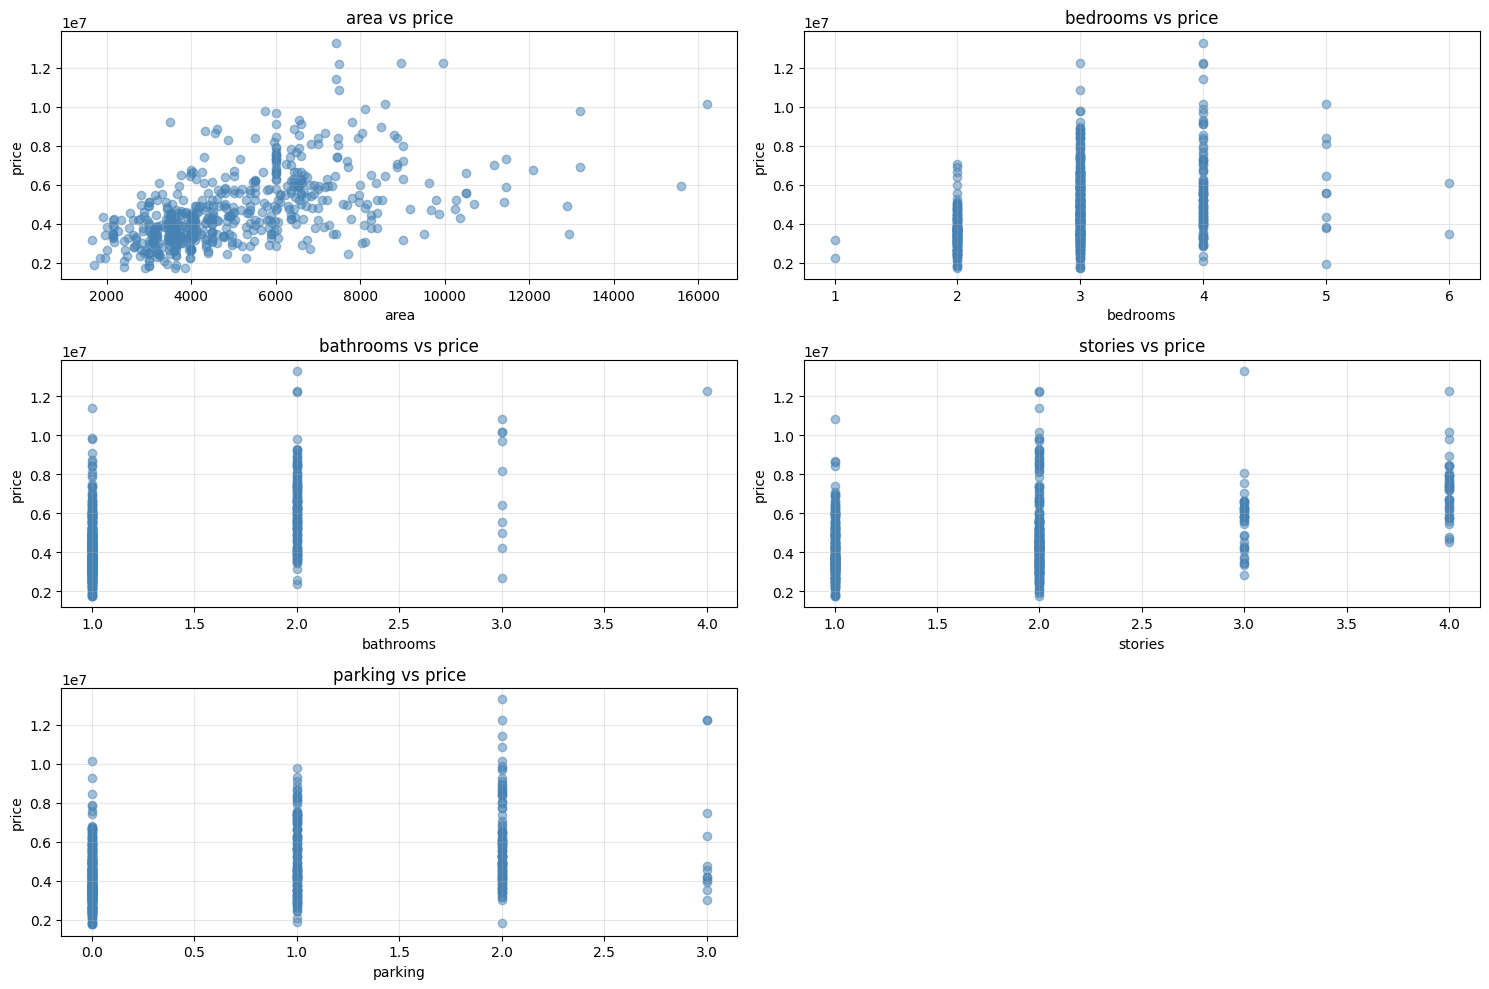

Model trained!
Coefficients: [ 2.35968805e+02  7.67787016e+04  1.09444479e+06  4.07476595e+05
  3.67919948e+05  2.31610037e+05  3.90251176e+05  6.84649885e+05
  7.91426736e+05  2.24841913e+05  6.29890565e+05  1.80175627e+05
  5.32938090e+04 -2.33469436e+05]
Intercept: 79856.73100297339
MSE: 1,754,318,687,330.66
RMSE: 1,324,506.96
R²: 0.6529


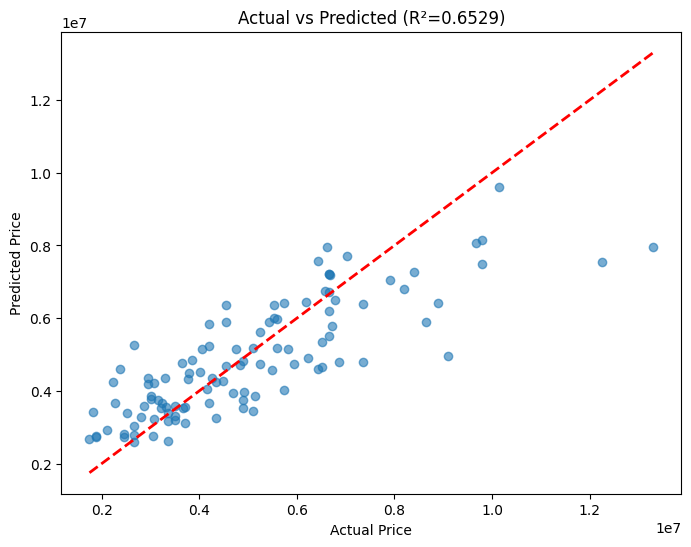

Predicted Price: ₹6,321,613.20


In [4]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# --- Data Collection and Loading ---
df = pd.read_csv('Housing.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# --- Quick Check of Data ---
print(df.head())
print(df.info())
print(df.describe())

# Identify feature types
continuous = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
categorical = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
print(f"Continuous: {continuous}")
print(f"Categorical: {categorical}")

# --- EDA and Data Preprocessing ---
print("Missing values:")
print(df.isnull().sum())  # No missing values

# --- Visualize: Scatter plots for continuous features vs price ---
continuous_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, feature in enumerate(continuous_features):
    axes[i].scatter(df[feature], df['price'], alpha=0.5, color='steelblue')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('price')
    axes[i].set_title(f'{feature} vs price')
axes[5].axis('off')
plt.tight_layout()
plt.show()

# --- Function to automate scatter plots ---
def plot_features_vs_target(df, features, target='price', figsize=(15, 10)):
    n_features = len(features)
    n_cols = 2
    n_rows = (n_features + 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_features > 1 else [axes]

    for i, feature in enumerate(features):
        axes[i].scatter(df[feature], df[target], alpha=0.5, color='steelblue')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(target)
        axes[i].set_title(f'{feature} vs {target}')
        axes[i].grid(True, alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

# Use the function
features_to_plot = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
plot_features_vs_target(df, features_to_plot, target='price')

# --- Encode categorical variables for modeling ---
df_encoded = df.copy()

# Binary encode yes/no columns
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'yes': 1, 'no': 0})

# One-hot encode furnishingstatus
furnishing_dummies = pd.get_dummies(df_encoded['furnishingstatus'], prefix='furnishing')
df_encoded = pd.concat([df_encoded.drop('furnishingstatus', axis=1), furnishing_dummies], axis=1)

# Convert boolean to int
df_encoded['furnishing_furnished'] = df_encoded['furnishing_furnished'].astype(int)
df_encoded['furnishing_semi-furnished'] = df_encoded['furnishing_semi-furnished'].astype(int)
df_encoded['furnishing_unfurnished'] = df_encoded['furnishing_unfurnished'].astype(int)

# --- ML Model Training ---
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained!")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# --- Model Evaluation ---
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.4f}")

# Actual vs Predicted plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted (R²={r2:.4f})')
plt.show()

# --- Model Prediction ---
new_data = pd.DataFrame({
    'area': [5000],
    'bedrooms': [3],
    'bathrooms': [2],
    'stories': [2],
    'mainroad': [1],
    'guestroom': [0],
    'basement': [1],
    'hotwaterheating': [0],
    'airconditioning': [1],
    'parking': [1],
    'prefarea': [0],
    'furnishing_furnished': [0],
    'furnishing_semi-furnished': [1],
    'furnishing_unfurnished': [0]
})

predicted_price = model.predict(new_data)
print(f"Predicted Price: ₹{predicted_price[0]:,.2f}")
